# Xenium Spatial Transcriptomics Integrative analysis
Integrate and analyze spatial transcriptomics data from Control and Case samples.



In [2]:
# import libraries
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import ListedColormap

## Data loading and cell type/IDH1 status annotation

In [3]:
# Data loading
adata_paths = {
    'Ctrl1': '/home/parkjw88/Xenium/Ctrl1/output-XETG00498__0052360__CTRL1__20250311__104112/adata_ctrl1_h_raw.h5ad',
    'Ctrl2': '/home/parkjw88/Xenium/Ctrl2/output-XETG00498__0028602__CTRL2__20250311__104113/adata_ctrl2_h_raw.h5ad',
    'Case1': '/home/parkjw88/Xenium/Case1/output-XETG00498__0052360__CASE1__20250311__104113/adata_case1_h_raw.h5ad',
    'Case2': '/home/parkjw88/Xenium/Case2/output-XETG00498__0052360__CASE2__20250311__104113/adata_case2_h_raw.h5ad',
    'Case3': '/home/parkjw88/Xenium/Case3/output-XETG00498__0052360__CASE3__20250311__104113/adata_case3_h_raw.h5ad',
    'Case5': '/home/parkjw88/Xenium/Case5/output-XETG00498__0028602__CASE5__20250311__104113/adata_case5_h_raw.h5ad'
}
adatas = {k: sc.read_h5ad(v) for k, v in adata_paths.items()}

# IDH1 status annotation
IDH1mut = 'NM_005896.4_ALT_394:A'
for ad in adatas.values():
    gene_idx = ad.var.index.get_loc(IDH1mut)
    expr = ad.X[:, gene_idx].toarray().flatten()
    ad.obs['IDH1_status'] = np.where(expr > 0, 'mutant', 'undetermined')

# cell type annotation
adata_annot = sc.read_h5ad('/home/parkjw88/Xenium/adata_combined_hl_annot.h5ad')
for k, ad in adatas.items():
    cells = adata_annot[adata_annot.obs['sample'] == k]
    ad.obs['cell_type'] = ad.obs['cell_id'].map(cells.obs.set_index('cell_id')['cell_type'])

## Data filtering and integration

In [4]:
# Remove Tumor cell and NA cell_type
exclude_types = ['Tumor_AS', 'Tumor_OD', 'TAM']
adata_filt = {}
for k, ad in adatas.items():
    ex_types = ['Tumor_AS'] if k == 'Ctrl1' else (['Tumor_OD'] if k == 'Ctrl2' else exclude_types)
    ad_f = ad[~ad.obs['cell_type'].isin(ex_types)].copy()
    ad_f = ad_f[~ad_f.obs['cell_type'].isna()].copy()
    ad_f.obs['sample'] = k
    adata_filt[k] = ad_f

# Integration
adata_all = sc.concat(list(adata_filt.values()), axis=0)

/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## QC and preprocessing

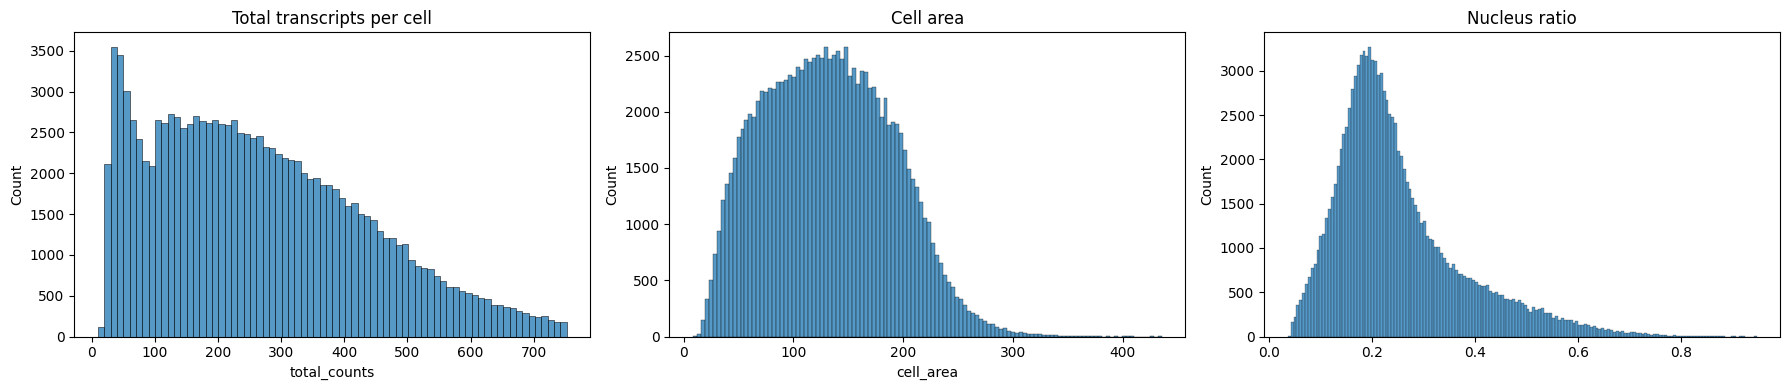

/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
# QC plot
fig, axs = plt.subplots(1, 3, figsize=(18,4))
sns.histplot(adata_all.obs['total_counts'], kde=False, ax=axs[0]); axs[0].set_title('Total transcripts per cell')
sns.histplot(adata_all.obs['cell_area'], kde=False, ax=axs[1]); axs[1].set_title('Cell area')
sns.histplot(adata_all.obs['nucleus_area'] / adata_all.obs['cell_area'], kde=False, ax=axs[2]); axs[2].set_title('Nucleus ratio')
plt.tight_layout(); plt.show()

# Preprocessing
sc.pp.filter_cells(adata_all, min_counts=10)
sc.pp.filter_genes(adata_all, min_cells=5)
adata_all.layers['counts'] = adata_all.X.copy()
sc.pp.normalize_total(adata_all, target_sum=100)
sc.pp.log1p(adata_all)
sc.pp.scale(adata_all)
sc.pp.pca(adata_all)
sc.pp.neighbors(adata_all, n_neighbors=16)
sc.tl.umap(adata_all)
sc.tl.louvain(adata_all)

## Defining a Color Palette

In [6]:
cell_type_colors = {
    'Tumor_AS': '#b3cae8', 'Tumor_OD': '#ffbe82', 'TAM': '#51ccd9', 'AS': '#ff8013',
    'Endo': '#3fa778', 'ExcNeu': '#d63738', 'InhNeu': '#aa44fc', 'MG': '#935f50',
    'OL': '#e48bc9', 'OPC': '#bcc376'
}
sample_colors = {
    'Ctrl1': '#1C7C54', 'Ctrl2': '#73E2A7', 'Case1': '#DEF4C6',
    'Case2': '#7DA37A', 'Case3': '#1B512D', 'Case5': '#B1CF5F'
}
idh_colors = ['#FF0000', '#BEBEBE']

## UMAP and Spatial Plot

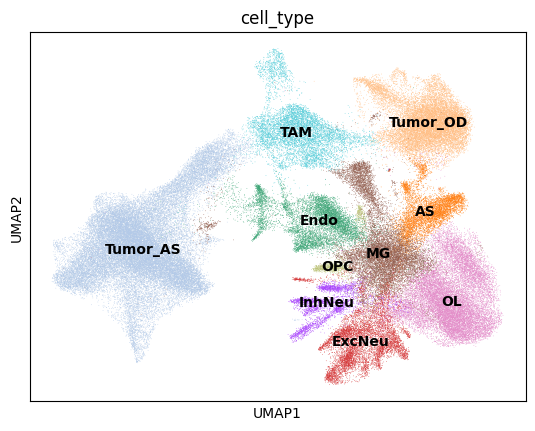

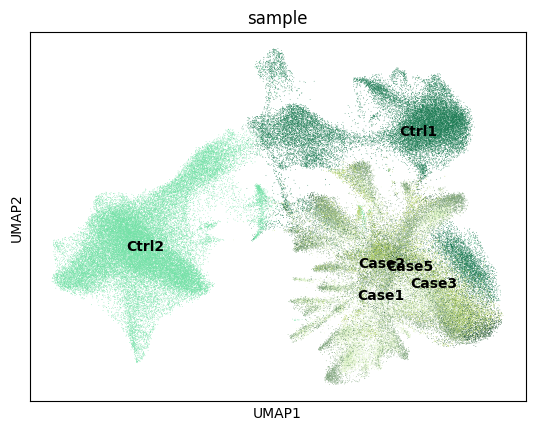

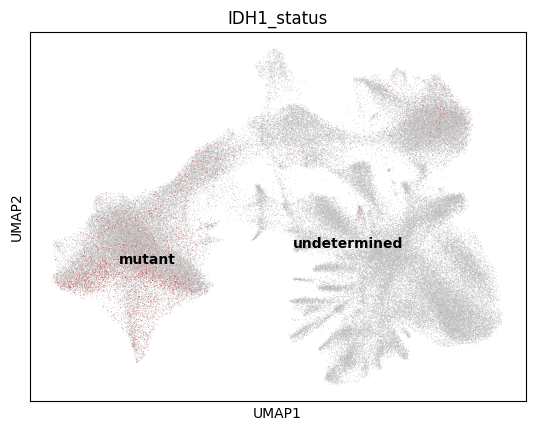

/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/parkjw88/miniforge3/envs/xenium_python/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: U

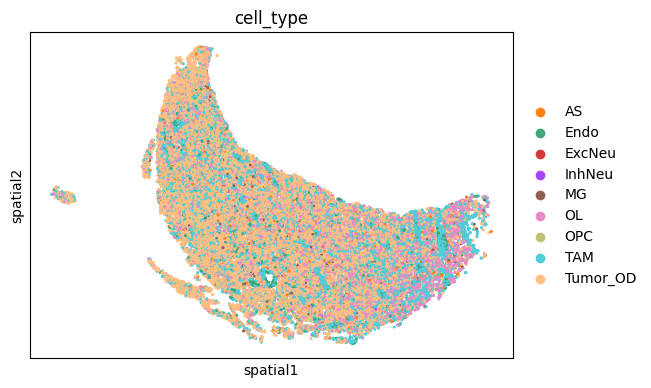

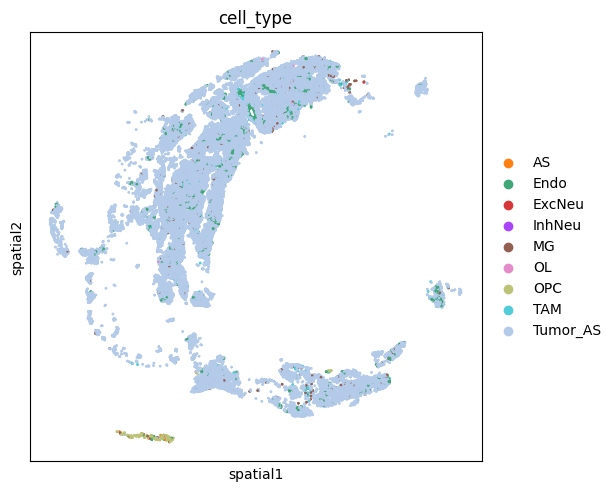

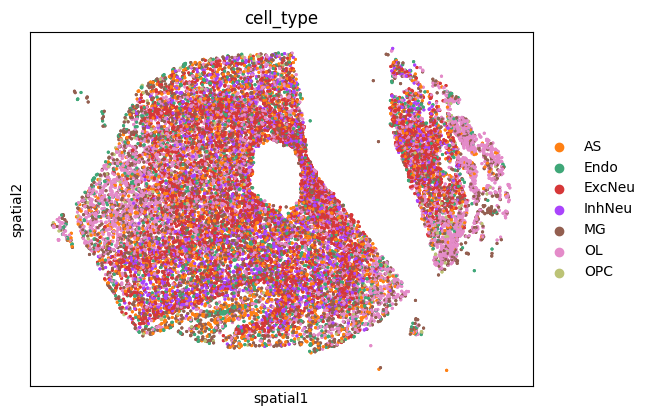

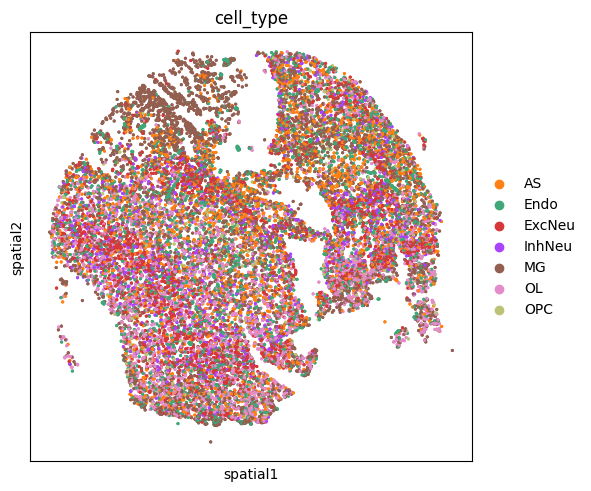

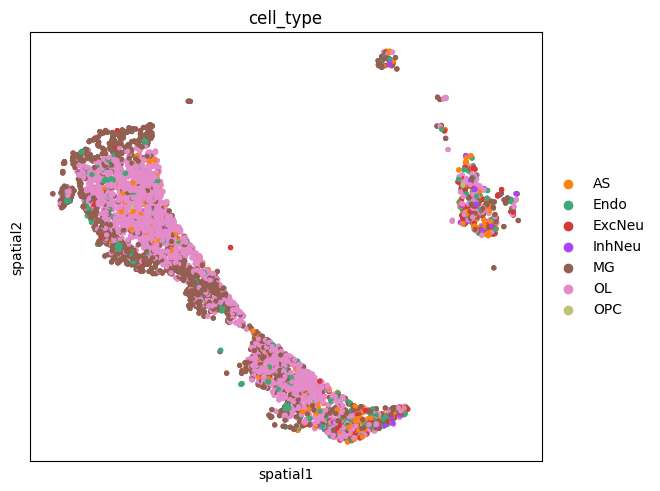

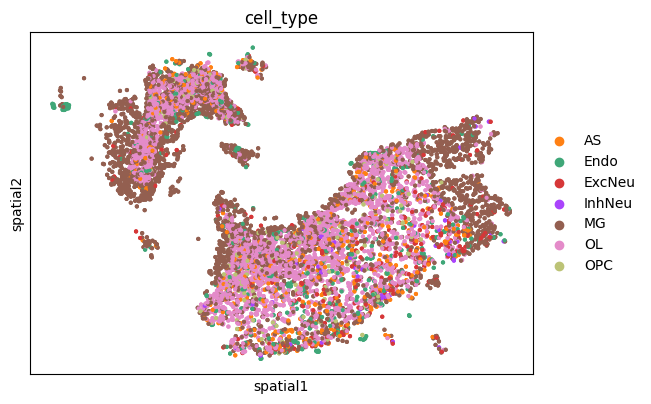

In [7]:
# Creat color lists for cell type, sample, and IDH1 status
def get_palette(adata, key, color_dict):
    cats = adata.obs[key].cat.categories if hasattr(adata.obs[key], 'cat') else sorted(adata.obs[key].unique())
    return [color_dict.get(cat, '#cccccc') for cat in cats]

# Combined UMAP plot
sc.pl.umap(adata_all, color=['cell_type'], palette=get_palette(adata_all, 'cell_type', cell_type_colors), legend_loc='on data')
sc.pl.umap(adata_all, color=['sample'], palette=get_palette(adata_all, 'sample', sample_colors), legend_loc='on data')
sc.pl.umap(adata_all, color=['IDH1_status'], palette=idh_colors, legend_loc='on data')

# Spatial plots by cell type (for each sample)
for k, ad in adata_filt.items():
    sq.pl.spatial_scatter(ad, library_id='spatial', shape=None, color=['cell_type'], palette=ListedColormap(get_palette(ad, 'cell_type', cell_type_colors)))

## Calculate the distribution and proportion of mutant cells

/tmp/ipykernel_2440495/1295032508.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mutant_counts = adata_all.obs.groupby('cell_type')['IDH1_status'].apply(lambda x: (x == 'mutant').sum())


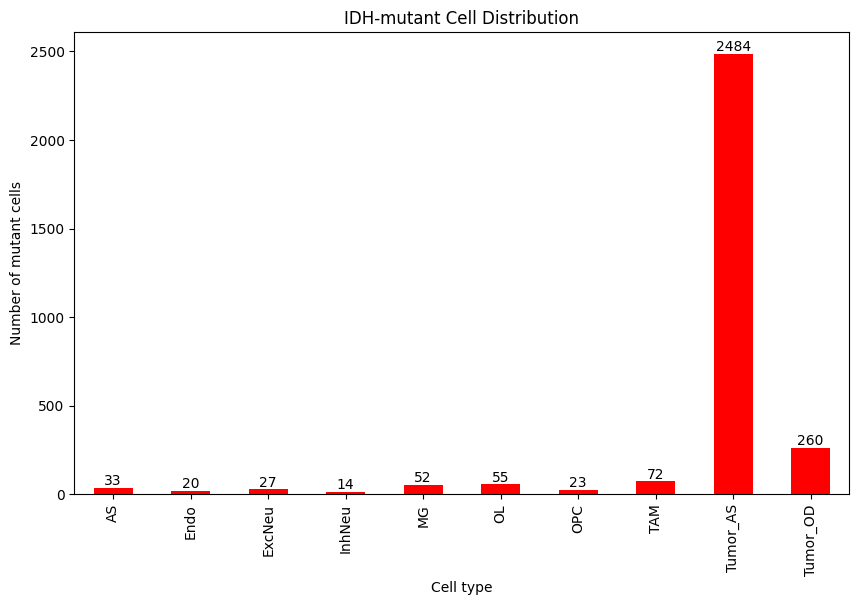

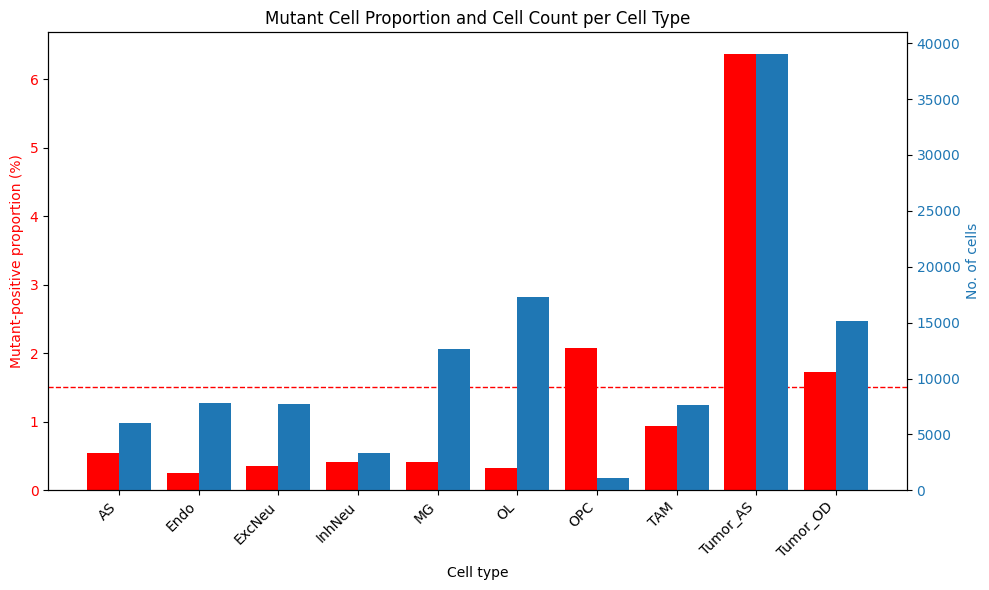

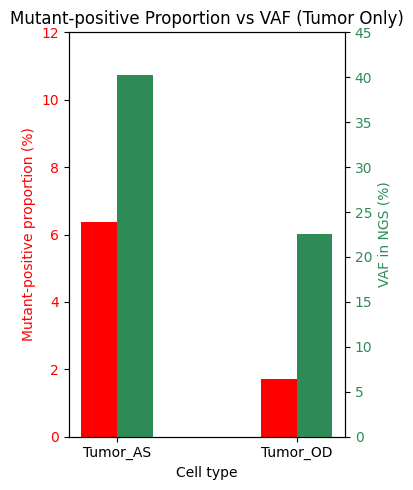

In [8]:
mutant_counts = adata_all.obs.groupby('cell_type')['IDH1_status'].apply(lambda x: (x == 'mutant').sum())
plt.figure(figsize=(10, 6))
ax = mutant_counts.plot(kind='bar', color='#FF0000')
for i, v in enumerate(mutant_counts):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=10)
plt.title('IDH-mutant Cell Distribution')
plt.xlabel('Cell type')
plt.ylabel('Number of mutant cells')
plt.show()

cell_type_counts = adata_all.obs['cell_type'].value_counts()
mutant_prop = mutant_counts / cell_type_counts * 100

# mutant proportion + cell count barplot
df = pd.DataFrame({
    'cell_type': mutant_prop.index,
    'mutant_proportion': mutant_prop.values,
    'No_cells': cell_type_counts.loc[mutant_prop.index].values
})
x = np.arange(len(df))
width = 0.4
fig, ax1 = plt.subplots(figsize=(10, 6))
bar1 = ax1.bar(x - width/2, df['mutant_proportion'], width=width, color='#ff0000', label='Mutant proportion (%)')
ax1.set_ylabel('Mutant-positive proportion (%)', color='#ff0000')
ax1.tick_params(axis='y', labelcolor='#ff0000')
ax1.axhline(y=1.5, color='#FF0000', linestyle='--', linewidth=1)
ax1.set_xlabel('Cell type')
plt.xticks(x, df['cell_type'], rotation=45, ha='right')

# Right side y axis (No. of cells)
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, df['No_cells'], width=width, color='#1f77b4', label='Number of cells')
ax2.set_ylabel('No. of cells', color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')

plt.title('Mutant Cell Proportion and Cell Count per Cell Type')
plt.tight_layout()
plt.show()

# Mutant cell proportion in tumor cell and VAF barplot
prop_VAF_data_tumor_only = pd.DataFrame({
    'cell_type': ['Tumor_AS', 'Tumor_OD'],
    'mutant_proportion': [6.361102, 1.716965],
    'VAF': [40.24, 22.6]
})

df = prop_VAF_data_tumor_only.sort_values(by='mutant_proportion', ascending=False)
x = np.arange(len(df))
width = 0.2
fig, ax1 = plt.subplots(figsize=(4, 5))
bar1 = ax1.bar(x - width/2, df['mutant_proportion'], width=width, color='#ff0000', label='Mutant proportion (%)')
ax1.set_ylabel('Mutant-positive proportion (%)', color='#ff0000')
ax1.tick_params(axis='y', labelcolor='#ff0000')
ax1.set_ylim(0, 12)

ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, df['VAF'], width=width, color='#2E8B57', label='VAF (%)')
ax2.set_ylabel('VAF in NGS (%)', color='#2E8B57')
ax2.tick_params(axis='y', labelcolor='#2E8B57')
ax2.set_ylim(0, 45)
plt.xticks(x, df['cell_type'], rotation=45, ha='right')
ax1.set_xlabel('Cell type')
plt.title('Mutant-positive Proportion vs VAF (Tumor Only)')
plt.tight_layout()
plt.show()

## Marker Gene Dotplot

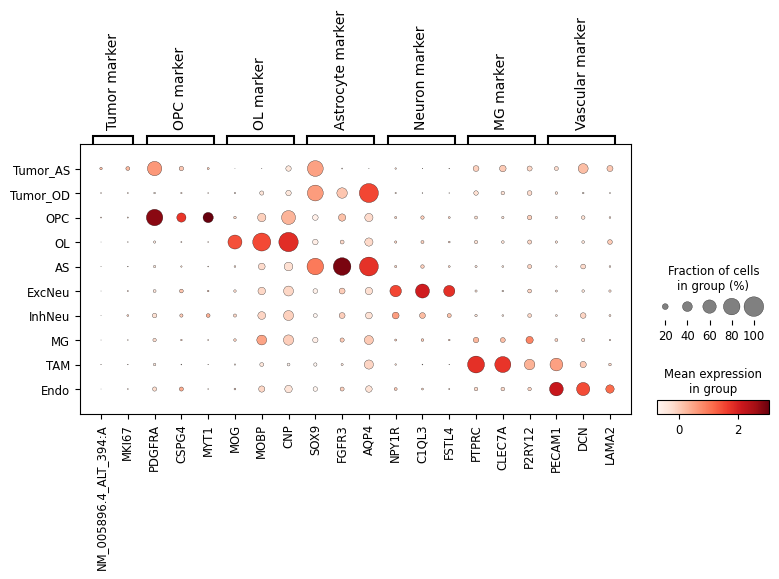

In [9]:
marker_genes = {
    'Tumor marker': ['NM_005896.4_ALT_394:A', 'MKI67'],
    'OPC marker': ['PDGFRA', 'CSPG4', 'MYT1'],
    'OL marker': ['MOG', 'MOBP', 'CNP'],
    'Astrocyte marker': ['SOX9', 'FGFR3', 'AQP4'],
    'Neuron marker': ['NPY1R', 'C1QL3', 'FSTL4'],
    'MG marker': ['PTPRC', 'CLEC7A', 'P2RY12'],
    'Vascular marker': ['PECAM1', 'DCN', 'LAMA2']
}
cell_type_order = ['Tumor_AS', 'Tumor_OD', 'OPC', 'OL', 'AS', 'ExcNeu', 'InhNeu', 'MG', 'TAM', 'Endo']
adata_all.obs['cell_type'] = pd.Categorical(adata_all.obs['cell_type'], categories=cell_type_order, ordered=True)
sc.pl.dotplot(adata_all, marker_genes, groupby='cell_type')

## Proportion barplot by sample

/tmp/ipykernel_2440495/2404336972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_sample_counts = adata_annot.obs.groupby(['cell_type', 'sample']).size().unstack(fill_value=0)


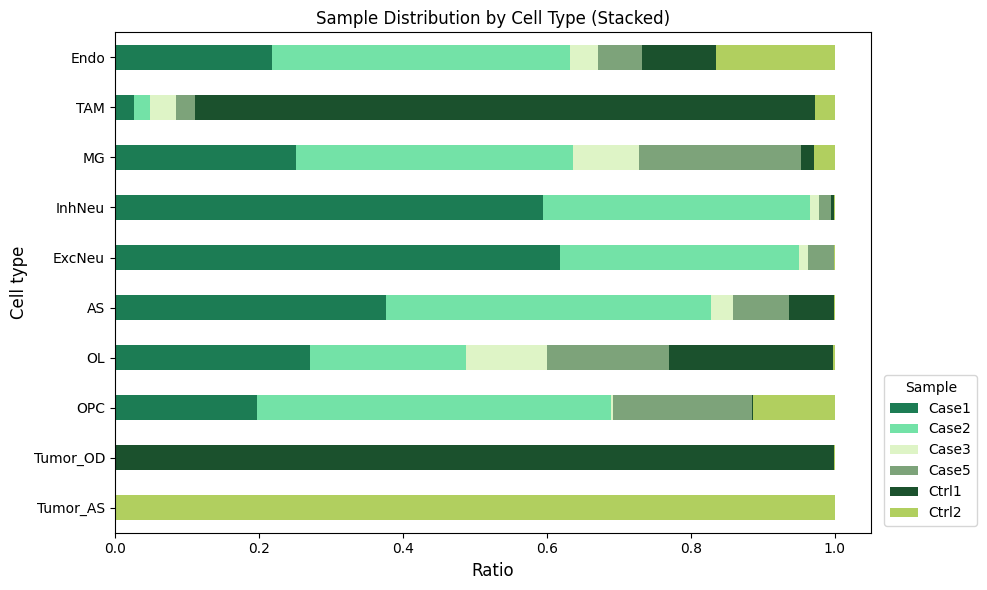

In [10]:
celltype_sample_counts = adata_annot.obs.groupby(['cell_type', 'sample']).size().unstack(fill_value=0)
celltype_sample_ratios = celltype_sample_counts.div(celltype_sample_counts.sum(axis=1), axis=0)
celltype_sample_ratios.index = pd.Categorical(celltype_sample_ratios.index, categories=cell_type_order, ordered=True)
celltype_sample_ratios = celltype_sample_ratios.sort_index()
ax = celltype_sample_ratios.plot(kind='barh', stacked=True, figsize=(10, 6), color=list(sample_colors.values()))
plt.title('Sample Distribution by Cell Type (Stacked)')
plt.ylabel('Cell type', fontsize=12)
plt.xlabel('Ratio', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Sample', bbox_to_anchor=(1.15, 0), loc='lower right')
plt.tight_layout()
plt.show()

## Saving all data

In [11]:
adata_all.write('/home/parkjw88/Xenium/adata_final_all.h5ad')